# Notebook 4 — Results Aggregation & Paper Figures (biplane)

Builds the **final ablation table** and the **figures** for Chapter 4.

- Reads CSVs from Notebooks 1–3.
- Builds the master per-view + biplane EF table.
- Plots five label-efficiency curves: Dice (2CH), Dice (4CH), HD95 (2CH), HD95 (4CH), biplane EF MAE — Supervised vs MAE-pretrained.
- MLP-vs-KAN bar chart for the EF head.
- Exports a LaTeX-ready table.

Run after Notebooks 1, 2, 3 have completed.

In [1]:
# Cell 1 — Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = 'results/'
FIGS_DIR = 'figures/'
os.makedirs(FIGS_DIR, exist_ok=True)

sup_path  = os.path.join(RESULTS_DIR, "supervised_baseline.csv")
mae_path  = os.path.join(RESULTS_DIR, "mae_finetune.csv")
head_path = os.path.join(RESULTS_DIR, "ef_head_comparison.csv")
for p in [sup_path, mae_path, head_path]:
    assert os.path.exists(p), f"Missing: {p}"
print("All CSVs found.")

All CSVs found.


In [2]:
# Cell 2 — Aggregate per-seed -> mean ± std per fraction
METRICS = ["dice_2CH","dice_4CH","dice_mean","hd95_2CH_mm","hd95_4CH_mm","ef_mae_biplane"]
def agg(df, label):
    rows = []
    for frac, g in df.groupby('fraction'):
        r = {"method": label, "fraction": frac, "n_train": int(g["n_train"].iloc[0])}
        for m in METRICS:
            r[f"{m}_mean"] = g[m].mean()
            r[f"{m}_std"]  = g[m].std()
        rows.append(r)
    return pd.DataFrame(rows)

sup = agg(pd.read_csv(sup_path), 'Supervised UNet')
mae = agg(pd.read_csv(mae_path), 'MAE + ViT-Tiny')
master = pd.concat([sup, mae], ignore_index=True).sort_values(['method', 'fraction'])
master.to_csv(os.path.join(RESULTS_DIR, "master_ablation_table.csv"), index=False)
print(master.to_string(index=False))

         method  fraction  n_train  dice_2CH_mean  dice_2CH_std  dice_4CH_mean  dice_4CH_std  dice_mean_mean  dice_mean_std  hd95_2CH_mm_mean  hd95_2CH_mm_std  hd95_4CH_mm_mean  hd95_4CH_mm_std  ef_mae_biplane_mean  ef_mae_biplane_std
 MAE + ViT-Tiny      0.01       16       0.191651      0.331949       0.199344      0.345274        0.195497       0.338611          7.615308              NaN          7.336074              NaN            22.869563                 NaN
 MAE + ViT-Tiny      0.05       80       0.827061      0.008629       0.823956      0.004356        0.825508       0.006221          3.906419         0.159394          4.559698         0.088383            19.724585            1.445535
 MAE + ViT-Tiny      0.10      160       0.861693      0.001805       0.863709      0.001246        0.862701       0.000447          3.089020         0.076223          3.532362         0.024145            12.648985            1.210216
 MAE + ViT-Tiny      1.00     1600       0.907349      0.000

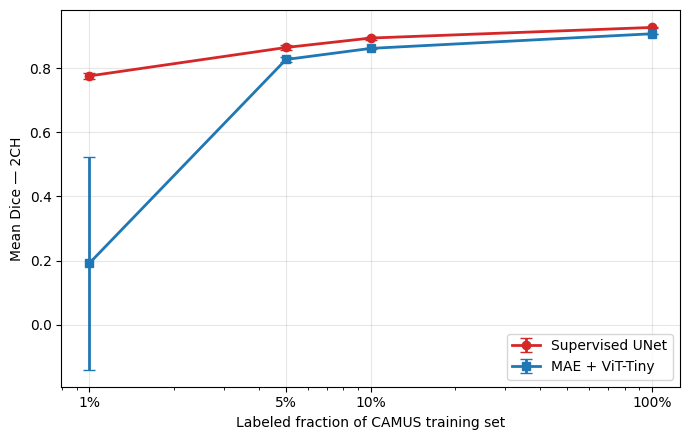

Saved: figures/label_eff_dice_2CH.png


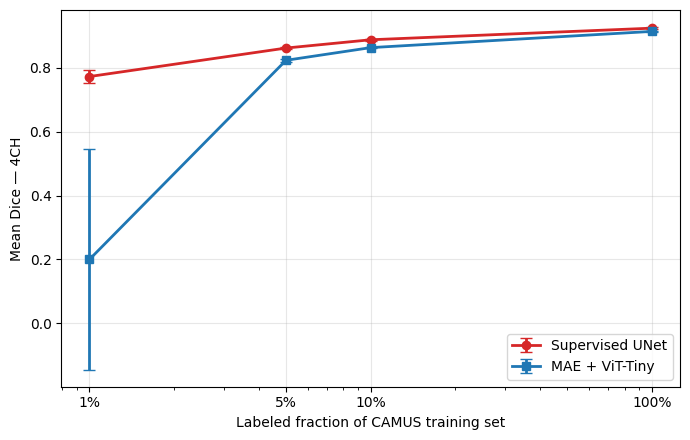

Saved: figures/label_eff_dice_4CH.png


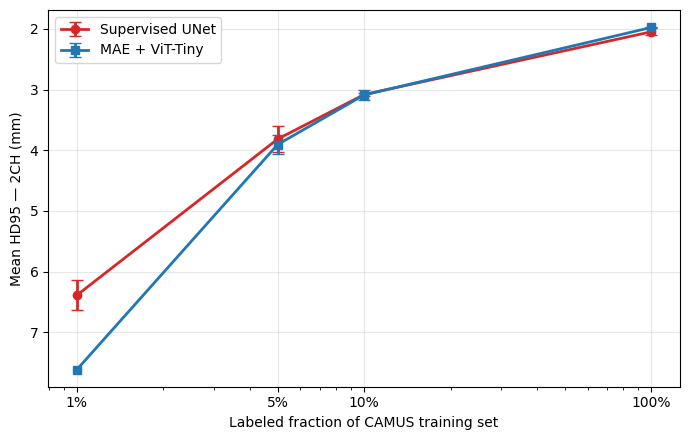

Saved: figures/label_eff_hd95_2CH.png


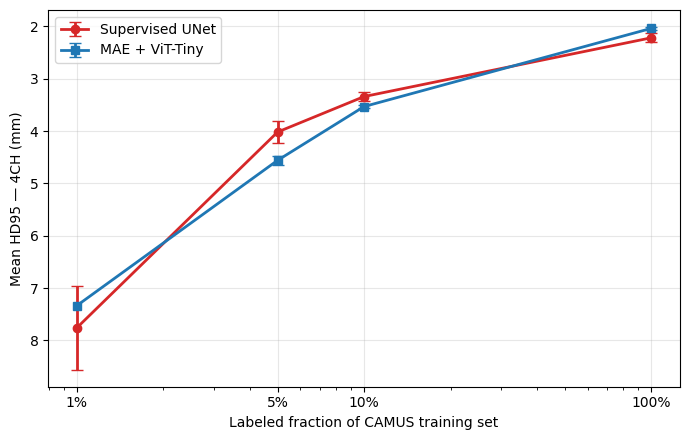

Saved: figures/label_eff_hd95_4CH.png


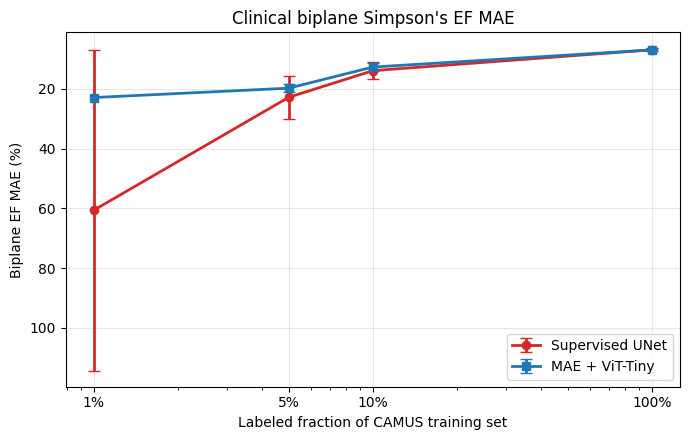

Saved: figures/label_eff_ef_biplane.png


In [3]:
# Cell 3 — Label-efficiency curves (5 figures)
def plot_metric(mean_col, std_col, ylabel, fname, invert=False, title=None):
    plt.figure(figsize=(7, 4.5))
    for method, color, marker in [('Supervised UNet', 'C3', 'o'),
                                  ('MAE + ViT-Tiny',  'C0', 's')]:
        sub = master[master['method'] == method].sort_values('fraction')
        x = (sub['fraction'] * 100).values
        y = sub[mean_col].values
        e = sub[std_col].values
        plt.errorbar(x, y, yerr=e, marker=marker, color=color,
                     linewidth=2, capsize=4, label=method)
    plt.xscale('log')
    plt.xticks([1, 5, 10, 100], ['1%', '5%', '10%', '100%'])
    plt.xlabel('Labeled fraction of CAMUS training set')
    plt.ylabel(ylabel)
    if title: plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    if invert: plt.gca().invert_yaxis()
    plt.tight_layout()
    out = os.path.join(FIGS_DIR, fname)
    plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
    print("Saved:", out)

plot_metric('dice_2CH_mean',     'dice_2CH_std',     'Mean Dice — 2CH',         'label_eff_dice_2CH.png')
plot_metric('dice_4CH_mean',     'dice_4CH_std',     'Mean Dice — 4CH',         'label_eff_dice_4CH.png')
plot_metric('hd95_2CH_mm_mean',  'hd95_2CH_mm_std',  'Mean HD95 — 2CH (mm)',    'label_eff_hd95_2CH.png', invert=True)
plot_metric('hd95_4CH_mm_mean',  'hd95_4CH_mm_std',  'Mean HD95 — 4CH (mm)',    'label_eff_hd95_4CH.png', invert=True)
plot_metric('ef_mae_biplane_mean','ef_mae_biplane_std','Biplane EF MAE (%)',    'label_eff_ef_biplane.png', invert=True,
            title='Clinical biplane Simpson\'s EF MAE')

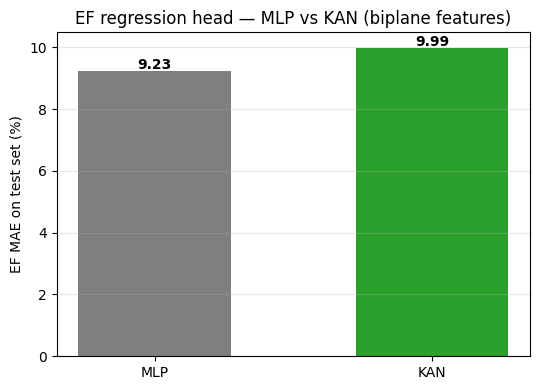

Saved: figures/ef_head_mlp_vs_kan.png


In [4]:
# Cell 4 — MLP vs KAN bar chart
head = pd.read_csv(head_path)
fig, ax = plt.subplots(figsize=(5.5, 4))
x = np.arange(len(head))
ax.bar(x, head['test_MAE'], width=0.55, color=['C7', 'C2'])
ax.set_xticks(x); ax.set_xticklabels(head['head'])
ax.set_ylabel('EF MAE on test set (%)')
ax.set_title('EF regression head — MLP vs KAN (biplane features)')
for i, v in enumerate(head['test_MAE']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out = os.path.join(FIGS_DIR, "ef_head_mlp_vs_kan.png")
plt.savefig(out, dpi=200, bbox_inches='tight'); plt.show()
print("Saved:", out)

In [5]:
# Cell 5 — LaTeX-ready ablation table
def latex_table(master):
    rows = [r"\begin{table}[ht]",
            r"\centering",
            r"\caption{Label-efficiency ablation on CAMUS. Per-view Dice and HD95 plus biplane Simpson's EF MAE. Mean $\pm$ std over 3 seeds on the 50-patient test set.}",
            r"\label{tab:ablation}",
            r"\begin{tabular}{l c c c c c c}",
            r"\hline",
            r"Method & Labels (\%) & Dice 2CH & Dice 4CH & HD95 2CH (mm) & HD95 4CH (mm) & EF MAE (\%) \\",
            r"\hline"]
    for _, r in master.sort_values(['method','fraction']).iterrows():
        rows.append(
            f"{r['method']} & {int(r['fraction']*100)} & "
            f"{r['dice_2CH_mean']:.3f}$\pm${r['dice_2CH_std']:.3f} & "
            f"{r['dice_4CH_mean']:.3f}$\pm${r['dice_4CH_std']:.3f} & "
            f"{r['hd95_2CH_mm_mean']:.2f}$\pm${r['hd95_2CH_mm_std']:.2f} & "
            f"{r['hd95_4CH_mm_mean']:.2f}$\pm${r['hd95_4CH_mm_std']:.2f} & "
            f"{r['ef_mae_biplane_mean']:.2f}$\pm${r['ef_mae_biplane_std']:.2f} \\")
    rows += [r"\hline", r"\end{tabular}", r"\end{table}"]
    return "\n".join(rows)

tex = latex_table(master)
with open(os.path.join(RESULTS_DIR, "ablation_table.tex"), "w") as f:
    f.write(tex)
print(tex)
print("\nWrote: results/ablation_table.tex")

\begin{table}[ht]
\centering
\caption{Label-efficiency ablation on CAMUS. Per-view Dice and HD95 plus biplane Simpson's EF MAE. Mean $\pm$ std over 3 seeds on the 50-patient test set.}
\label{tab:ablation}
\begin{tabular}{l c c c c c c}
\hline
Method & Labels (\%) & Dice 2CH & Dice 4CH & HD95 2CH (mm) & HD95 4CH (mm) & EF MAE (\%) \\
\hline
MAE + ViT-Tiny & 1 & 0.192$\pm$0.332 & 0.199$\pm$0.345 & 7.62$\pm$nan & 7.34$\pm$nan & 22.87$\pm$nan \
MAE + ViT-Tiny & 5 & 0.827$\pm$0.009 & 0.824$\pm$0.004 & 3.91$\pm$0.16 & 4.56$\pm$0.09 & 19.72$\pm$1.45 \
MAE + ViT-Tiny & 10 & 0.862$\pm$0.002 & 0.864$\pm$0.001 & 3.09$\pm$0.08 & 3.53$\pm$0.02 & 12.65$\pm$1.21 \
MAE + ViT-Tiny & 100 & 0.907$\pm$0.000 & 0.915$\pm$0.001 & 1.98$\pm$0.01 & 2.04$\pm$0.02 & 6.89$\pm$0.30 \
Supervised UNet & 1 & 0.776$\pm$0.010 & 0.773$\pm$0.019 & 6.39$\pm$0.24 & 7.76$\pm$0.80 & 60.66$\pm$53.72 \
Supervised UNet & 5 & 0.865$\pm$0.007 & 0.862$\pm$0.002 & 3.82$\pm$0.22 & 4.02$\pm$0.21 & 22.79$\pm$7.22 \
Supervised UNet & 1

In [6]:
# Cell 6 — Plain-text summary
lines = ["=" * 80, "FINAL RESULTS SUMMARY (biplane, both views, 3 seeds)", "=" * 80, ""]
for method in master['method'].unique():
    lines.append(f"--- {method} ---")
    sub = master[master['method'] == method].sort_values('fraction')
    for _, r in sub.iterrows():
        lines.append(
            f"  {int(r['fraction']*100):>3}% labels (n_train={r['n_train']:>4}) | "
            f"Dice 2CH {r['dice_2CH_mean']:.3f}±{r['dice_2CH_std']:.3f}  "
            f"4CH {r['dice_4CH_mean']:.3f}±{r['dice_4CH_std']:.3f} | "
            f"HD95 2CH {r['hd95_2CH_mm_mean']:5.2f}  "
            f"4CH {r['hd95_4CH_mm_mean']:5.2f} mm | "
            f"biplane EF MAE {r['ef_mae_biplane_mean']:5.2f}±{r['ef_mae_biplane_std']:.2f}%")
    lines.append("")
lines.append("--- EF regression head (Notebook 3) ---")
for _, r in pd.read_csv(head_path).iterrows():
    lines.append(f"  {r['head']:<4}  test EF MAE = {r['test_MAE']:.2f}%")
out = "\n".join(lines)
print(out)
with open(os.path.join(RESULTS_DIR, "summary.txt"), "w") as f:
    f.write(out)
print("\nWrote: results/summary.txt")

FINAL RESULTS SUMMARY (biplane, both views, 3 seeds)

--- MAE + ViT-Tiny ---
    1% labels (n_train=  16) | Dice 2CH 0.192±0.332  4CH 0.199±0.345 | HD95 2CH  7.62  4CH  7.34 mm | biplane EF MAE 22.87±nan%
    5% labels (n_train=  80) | Dice 2CH 0.827±0.009  4CH 0.824±0.004 | HD95 2CH  3.91  4CH  4.56 mm | biplane EF MAE 19.72±1.45%
   10% labels (n_train= 160) | Dice 2CH 0.862±0.002  4CH 0.864±0.001 | HD95 2CH  3.09  4CH  3.53 mm | biplane EF MAE 12.65±1.21%
  100% labels (n_train=1600) | Dice 2CH 0.907±0.000  4CH 0.915±0.001 | HD95 2CH  1.98  4CH  2.04 mm | biplane EF MAE  6.89±0.30%

--- Supervised UNet ---
    1% labels (n_train=  16) | Dice 2CH 0.776±0.010  4CH 0.773±0.019 | HD95 2CH  6.39  4CH  7.76 mm | biplane EF MAE 60.66±53.72%
    5% labels (n_train=  80) | Dice 2CH 0.865±0.007  4CH 0.862±0.002 | HD95 2CH  3.82  4CH  4.02 mm | biplane EF MAE 22.79±7.22%
   10% labels (n_train= 160) | Dice 2CH 0.894±0.005  4CH 0.888±0.004 | HD95 2CH  3.08  4CH  3.34 mm | biplane EF MAE 13.86±2